# Metagenome sample Host genome signal analysis
***
- for 3k metagenomes, we wonder **how much host signal are** and their **compact on the microbe metagenome  assembly**
- we use **Sourmash manysearch** to find host signal using **8 common livestock query genomes**:
                                     
    - bosTau9.fa.gz   -- cattle
    - canFam6.fa.gz   -- dog
    - felCat9.fa.gz   -- cat
    - galGal6.fa.gz   -- chicken
    - hg38.all        -- human
    - mm39.fa.gz      -- mouse
    - oviAri4.fa.gz   -- sheep
    - susScr11.fa.gz  -- pig

    > `srun -p high2 –time=2-00:00:00 –nodes=1 -c 12 –mem 48GB –pty /bin/bash`
    > `/usr/bin/time -v sourmash scripts manysearch all-host.mf.csv ../list/zyzhao-sigpaths-oct4.txt -o 3k.csv -c 4 -t 0 –scale=10_000 > 3k.time.out`

- The <u>downstream analysis</u> steps are:

    1) covert **3k.time.out** to **hg.csv**, load & calculate "p_genome" (percentage of query/host genomes in the metagenome sample) 'mean', 'min', 'max', 'sum'
    - query is the host genome type
    - p_genome is the fraction of the genome covered by the metagenome ("detection");
    - avg_abund is the average abundance of that genome in the metagenome (~mapping abundance);
    - p_metag is the fraction of the metagenome that would map to that genome;
    
    2) Calculate the number of metagenomes with **p_metag > # %** for each query (which host was detected at what level) 
    
    3) make scatter plot, x-asix is the eight "Query" genomes, y-asix are percentage of genomes detected
    
    4) update plot, **Color coding** based on the `metagenome`,** dot size**, representing `p_metag`
    
    5) make interative plot, color associated with each metagenome.

In [42]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [43]:
# Load the data
data = pd.read_csv('../../data/3k.hg.csv')
data

,query,p_genome,avg_abund,p_metag,metagenome name
0,bosTau9.fa.gz,0.00%,1.0,0.00%,ERR9456920
1,bosTau9.fa.gz,0.00%,1.2,0.00%,ERR3610816
2,bosTau9.fa.gz,0.00%,1.0,0.00%,SRR7664969
3,bosTau9.fa.gz,0.00%,20.2,0.10%,SRR12180980
4,bosTau9.fa.gz,0.00%,3.2,0.00%,SRR6713626
...,...,...,...,...,...
19440,susScr11.fa.gz,0.00%,7.9,0.10%,SRR5808817
19441,susScr11.fa.gz,0.00%,1.5,0.00%,SRR10810041
19442,susScr11.fa.gz,0.00%,2.6,0.00%,ERR2607371
19443,susScr11.fa.gz,0.00%,12.6,0.10%,SRR12180994


In [44]:
# quick look at the statistic of how many metagenomes has host signals, using p_metag
data['p_metag'] = data['p_metag'].str.rstrip('%').astype(float)

# Group by 'query' and calculate statistics
result = data.groupby('query')['p_metag'].agg(['mean', 'min', 'max', 'sum'])

print(result)

                    mean  min   max     sum
query                                      
bosTau9.fa.gz   0.218405  0.0  89.2   498.4
canFam6.fa.gz   0.145415  0.0   8.7   364.7
felCat9.fa.gz   0.200283  0.0   8.7   495.7
galGal6.fa.gz   0.311051  0.0  57.8   751.5
hg38.all        1.283894  0.0  88.6  3204.6
mm39.fa.gz      1.864554  0.0  88.8  4618.5
oviAri4.fa.gz   0.157071  0.0  38.5   376.5
susScr11.fa.gz  0.175564  0.0  39.3   420.3


In [32]:
# Calculate the number of metagenomes with p_metag > # % for each query

count_p_metag_gt_50= data[data['p_metag'] > 50].groupby('query').size()

# Add this information to the result table
result['count_p_metag_gt_50'] = result.index.map(count_p_metag_gt_50).fillna(0).astype(int)

# Display the updated result
print(result)

                    mean  min   max     sum  count_p_metag_gt_50
query                                                           
bosTau9.fa.gz   0.218405  0.0  89.2   498.4                    4
canFam6.fa.gz   0.145415  0.0   8.7   364.7                    0
felCat9.fa.gz   0.200283  0.0   8.7   495.7                    0
galGal6.fa.gz   0.311051  0.0  57.8   751.5                    3
hg38.all        1.283894  0.0  88.6  3204.6                   29
mm39.fa.gz      1.864554  0.0  88.8  4618.5                   24
oviAri4.fa.gz   0.157071  0.0  38.5   376.5                    0
susScr11.fa.gz  0.175564  0.0  39.3   420.3                    0


In [33]:
# Calculate the number of metagenomes with p_metag > # % for each query

count_p_metag_lt_5= data[data['p_metag'] < 5].groupby('query').size()

# Add this information to the result table
result['count_p_metag_lt_5'] = result.index.map(count_p_metag_lt_5).fillna(0).astype(int)

# Display the updated result
print(result)

                    mean  min   max     sum  count_p_metag_gt_50  \
query                                                              
bosTau9.fa.gz   0.218405  0.0  89.2   498.4                    4   
canFam6.fa.gz   0.145415  0.0   8.7   364.7                    0   
felCat9.fa.gz   0.200283  0.0   8.7   495.7                    0   
galGal6.fa.gz   0.311051  0.0  57.8   751.5                    3   
hg38.all        1.283894  0.0  88.6  3204.6                   29   
mm39.fa.gz      1.864554  0.0  88.8  4618.5                   24   
oviAri4.fa.gz   0.157071  0.0  38.5   376.5                    0   
susScr11.fa.gz  0.175564  0.0  39.3   420.3                    0   

                count_p_metag_lt_5  
query                               
bosTau9.fa.gz                 2276  
canFam6.fa.gz                 2506  
felCat9.fa.gz                 2447  
galGal6.fa.gz                 2395  
hg38.all                      2430  
mm39.fa.gz                    2280  
oviAri4.fa.gz          

In [34]:
# Curious about given one metagenome sample, if it contains multiple host signal
# Calculate the number of different hosts detected in the metagenome

# Filter rows with host signals (p_metag > 1)
signal_data = data[data["p_metag"] > 1]

# Count the number of unique hosts signal in each metagenome
host_signal_counts = signal_data.groupby("metagenome name")["query"].nunique()

# Count the number of metagenomes for each level of host signal
signal_summary = host_signal_counts.value_counts().sort_index()

# Convert to a DataFrame for better visualization
signal_table = signal_summary.reset_index()
signal_table.columns = ["Number of Host signals (p_metag > 2%)", "Number of Metagenomes"]

# Display the table
print(signal_table)

   Number of Host signals (p_metag > 2%)  Number of Metagenomes
0                                      1                    457
1                                      2                     24
2                                      3                     56
3                                      5                      4
4                                      6                      2
5                                      7                     16
6                                      8                      6


In [38]:
# list of metagenomes with # of hosts

one_host = host_signal_counts[host_signal_counts == 1].index.tolist()
two_hosts = host_signal_counts[host_signal_counts == 2].index.tolist()
three_hosts = host_signal_counts[host_signal_counts == 3].index.tolist()
four_hosts = host_signal_counts[host_signal_counts == 4].index.tolist()
five_hosts = host_signal_counts[host_signal_counts == 5].index.tolist()
six_hosts = host_signal_counts[host_signal_counts == 6].index.tolist()
seven_hosts = host_signal_counts[host_signal_counts == 7].index.tolist()
eight_hosts = host_signal_counts[host_signal_counts == 8].index.tolist()

print("Metagenomes with seven host signals:", seven_hosts)
#print("Metagenomes with two host signals:", two_hosts)
#print("Metagenomes with three host signals:", three_hosts)

Metagenomes with seven host signals: ['ERR2241789', 'ERR2245452', 'ERR2245457', 'ERR2245459', 'ERR2245478', 'ERR2245479', 'ERR2245483', 'ERR2592328', 'ERR2592331', 'ERR2592336', 'ERR2592339', 'ERR2592340', 'ERR2592342', 'ERR2607376', 'ERR2607420', 'ERR2607489']


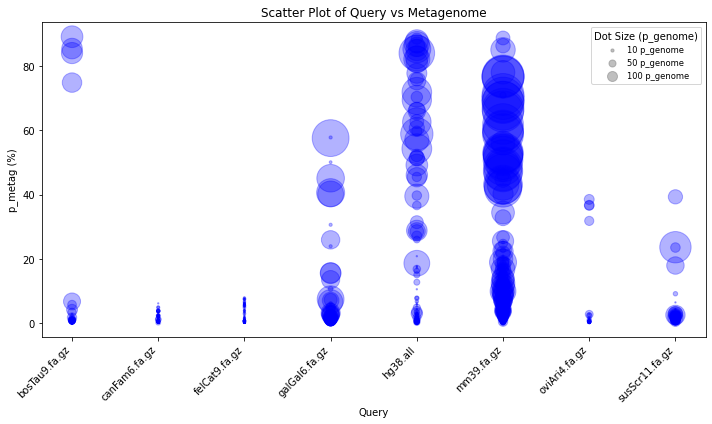

In [40]:
# plot all metagenomes that have host signals (p_metag > 0)
data = pd.read_csv('../../data/3k.hg.csv')

# Convert p_genome and p_metag columns to numeric after stripping the '%' sign
data["p_genome"] = data["p_genome"].str.rstrip('%').astype(float)
data["p_metag"] = data["p_metag"].str.rstrip('%').astype(float)

# Filter data to include only rows where p_metag > 0
filtered_data = data[data["p_metag"] > 0]

# Plot scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    filtered_data["query"], 
    filtered_data["p_metag"], 
    s=filtered_data["p_genome"] * 20,  # Scale dot size based on p_genome
    alpha=0.3, 
    c="blue"
)

# Add size legend for dots
for size in [10, 50, 100]:
    plt.scatter([], [], s=size, c='gray', alpha=0.5, label=f'{size} p_genome')
#    plt.scatter([], [], s=size, c='gray', alpha=0.5, label=f'{size/20} p_genome')
    
# Add size legend to the plot
plt.legend(title="Dot Size (p_genome)", loc="upper right", fontsize='small')

plt.xlabel("Query")
plt.ylabel("p_metag (%)")
plt.title("Scatter Plot of Query vs Metagenome")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

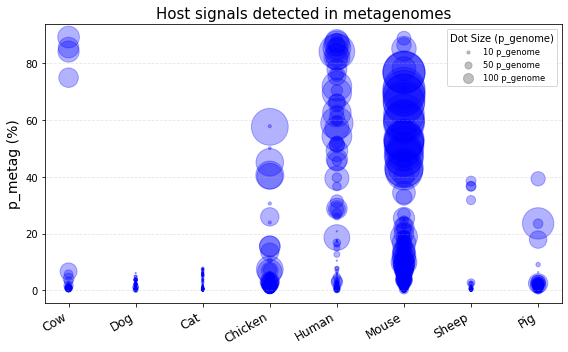

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Host mapping
# -------------------------
host_map = {
    "bosTau9.fa.gz": "Cow",
    "canFam6.fa.gz": "Dog",
    "felCat9.fa.gz": "Cat",
    "galGal6.fa.gz": "Chicken",
    "hg38.all": "Human",
    "mm39.fa.gz": "Mouse",
    "oviAri4.fa.gz": "Sheep",
    "susScr11.fa.gz": "Pig"
}
# -------------------------
# Load data
# -------------------------
data = pd.read_csv('../../data/3k.hg.csv')

# Convert percent columns
data["p_genome"] = data["p_genome"].str.rstrip('%').astype(float)
data["p_metag"] = data["p_metag"].str.rstrip('%').astype(float)

# Replace file names with common names
data["host"] = data["query"].map(host_map)

# Filter host
filtered_data = data[data["p_metag"] > 0]

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8,5))
plt.scatter(
    filtered_data["host"],
    filtered_data["p_metag"],
    s=filtered_data["p_genome"] * 20, # Scale dot size based on p_genome
    alpha=0.3,
    color="blue"
)

# -------------------------
# Dot size legend
# -------------------------
for size in [10, 50, 100]:
    plt.scatter([], [], s=size, color="gray", alpha=0.5,label=f'{size} p_genome')

plt.legend(title="Dot Size (p_genome)", loc="upper right", fontsize='small')

# -------------------------
# Formatting
# -------------------------
plt.ylabel("p_metag (%)", fontsize=14)
plt.title("Host signals detected in metagenomes", fontsize=15)

plt.xticks(rotation=30, ha="right", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
mm39_data = data[data["query"] == "mm39.fa.gz"].sort_values(by="p_metag", ascending=False)

# Select relevant columns for display
mm39_data_sorted = mm39_data[["query", "p_genome", "avg_abund", "p_metag", "metagenome name"]]

# Filter rows where p_genome is greater than 10%
filtered_mm39_data = mm39_data_sorted[mm39_data_sorted["p_metag"] > 5]

# Display the filtered data
print(filtered_mm39_data)

            query  p_genome  avg_abund  p_metag metagenome name
14018  mm39.fa.gz       9.6        1.6     88.8      ERR3357570
14133  mm39.fa.gz      10.5        1.5     86.4      ERR3357553
13983  mm39.fa.gz      30.0        1.8     85.1     SRR15429254
13097  mm39.fa.gz      28.0        1.7     78.1     SRR15429253
14143  mm39.fa.gz      89.4        4.3     76.9     SRR18439531
...           ...       ...        ...      ...             ...
13550  mm39.fa.gz       0.0        1.2      5.3       ERR346236
12590  mm39.fa.gz       3.1        1.5      5.3     SRR14920981
14388  mm39.fa.gz       0.0        1.1      5.3      SRR5790649
12797  mm39.fa.gz       0.0       70.9      5.2      ERR3593375
13203  mm39.fa.gz       3.0        1.2      5.1      SRR7664954

[195 rows x 5 columns]


The scatter plot has been updated, including:

1. **Color coding** based on the `metagenome name`.
2. A **legend for dot size**, representing `p_metag`.
3. A **legend for metagenome names**, indicating the color associated with each metagenome.

/var/folders/s9/2gscp4217xx30p4htg050dx40000gp/T/ipykernel_58304/3053134527.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



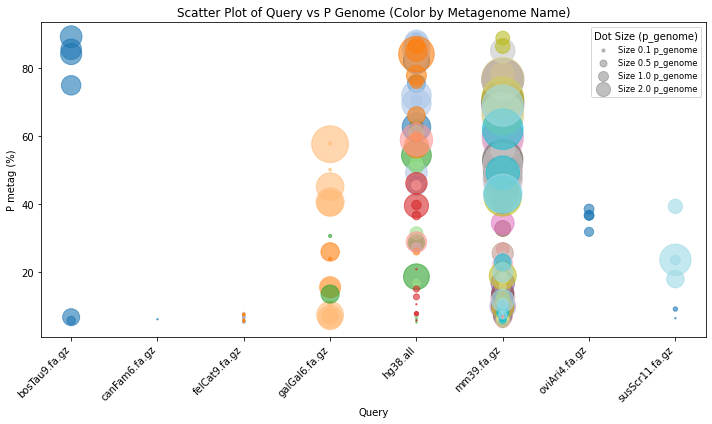

In [23]:
# Load the uploaded CSV file
file_path = '../../data/3k.hg.csv'

# Load the data from the uploaded CSV
data = pd.read_csv(file_path)

# Convert p_genome and p_metag columns to numeric after stripping the '%' sign
data["p_genome"] = data["p_genome"].str.rstrip('%').astype(float)
data["p_metag"] = data["p_metag"].str.rstrip('%').astype(float)

# Filter data to include only rows where p_genome > 0
filtered_data = data[data["p_metag"] > 5]

# Assign unique colors for metagenome names
unique_metagenomes = filtered_data["metagenome name"].unique()
colors = cm.tab20(np.linspace(0, 1, len(unique_metagenomes)))  # Diverse colors
color_map = dict(zip(unique_metagenomes, colors))
filtered_data["color"] = filtered_data["metagenome name"].map(color_map)

# Plot scatter plot with legend for metagenome names and dot size
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(
    filtered_data["query"],
    filtered_data["p_metag"],
    s=filtered_data["p_genome"] * 20,  # Scale dot size based on p_metag
    c=filtered_data["color"],  # Color based on metagenome name
    alpha=0.6,
    marker='o'
)

# Add size legend for dots
for size in [10, 50, 100, 200]:
    plt.scatter([], [], s=size, c='gray', alpha=0.5, label=f'Size {size/100} p_genome')

# Add legend for metagenome names
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, alpha=0.6)
           for color in color_map.values()]
labels = color_map.keys()
# legend_metagenome = plt.legend(handles, labels, title="Metagenome Name", loc="upper left", fontsize='small')
# plt.gca().add_artist(legend_metagenome)  # Add the metagenome legend first

# Add size legend to the plot
plt.legend(title="Dot Size (p_genome)", loc="upper right", fontsize='small')

# Add axis labels and title
plt.xlabel("Query")
plt.ylabel("P metag (%)")
plt.title("Scatter Plot of Query vs P Genome (Color by Metagenome Name)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
import plotly.express as px

# Filter the data (assuming `data` is already loaded and processed)
filtered_high_p_metag = data[data["p_metag"] > 5]

# Create an interactive scatter plot
fig = px.scatter(
    filtered_high_p_metag,
    x="query",
    y="p_metag",
    size="p_genome",  # Dot size based on p_genome
    color="metagenome name",  # Dot color based on metagenome name
    title="Interactive Scatter Plot of Query vs P Genome (p_metag > 5%)",
    labels={"query": "Query", "p_metag": "P metag (%)"},
    hover_data=["metagenome name", "avg_abund", "p_genome"]
)

# Show the interactive chart
fig.show()